# Aux Functions

In [2]:
import pandas as pd
import numpy as np
from CustomCallback import SaveTrainingRewardsCallback
from stable_baselines3.common.callbacks import CallbackList

c:\Users\tcorn\Desktop\RLTesis\DRLST\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def filter_data_for_testing(data, date_list):
    filtered_data = {}
    for ticker, df in data.items():
        normalized_index = df.index.normalize()
        index_dates = pd.Series(normalized_index.date, index=df.index)
        filtered_df = df.loc[index_dates.isin(date_list)]
        nonsense_timestamp = pd.Timestamp('9999-12-31 23:59:59-04:00')
        placeholder_data = {
            'Open': 1,
            'High': 1,
            'Low': 1,
            'Close': 1,
            'Volume': 1,
            'MACD': 1,
            'Signal': 1,
            'RSI': 1,
            'CCI': 1,
            'ADX': 1
        }
        placeholder_row = pd.DataFrame([placeholder_data], index=[nonsense_timestamp])
        filtered_data[ticker] = pd.concat([filtered_df, placeholder_row])
    return filtered_data

def getResumeMetrics(env, agents, episode_step_const, n_total_episodes=50, testing_points=5, just_test=False):
    metrics_resume = {}
    training_rewards_resume = {}
    trained_agents = {}         
    for agent_name, agent in agents.items():
        #print(f"Testing {agent_name}...")
        metrics_resume[agent_name], training_rewards_resume[agent_name], trained_agents[agent_name] = train_test_agent(env, agent, episode_step_const, n_total_episodes, testing_points,just_test)
        #print(f"Done testing {agent_name}!")
    
    #print('-'*50)
    #print('All agents tested!')
    #print('-'*50)

    return metrics_resume, training_rewards_resume , trained_agents


def train_test_agent(env, agent, episode_step_const, n_total_episodes=100, testing_points=10, just_test=False):
    """
    Test a single agent and track performance metrics, with an option to visualize the results.
    #TODO Corregir documentacion
    Parameters:
    - env: The trading environment.
    - agent: The agent to be tested.
    - stock_data: Data for the stocks in the environment.
    - n_tests: Number of tests to run (default: 1000).
    - visualize: Boolean flag to enable or disable visualization (default: False).

    Returns:
    - A dictionary containing steps, balances, net worths, and shares held.
    """
    # Initialize metrics tracking
    metrics = {
        'dates': [],
        'net_worths_delta': [],
        'shares_held': [],
        'pearson_correlations': [],
        'rewards': [],
        'portfolio_returns': [],
        'stds': [],
        'sharpe_ratios': [],
        'net_worths': []
    }

    # Reset the environment before starting the tests
    obs = np.array([env.env_method('hard_reset')[0][0].tolist()]) # env.reset()#

    # Get the training partition number of episodes
    partition = int(n_total_episodes / testing_points) - 1

    training_rewards = []

    # Set the episode loop
    for i_tpoint in range(testing_points):
        # First Evaluate the agents
        print(f"--------------Testing Point {i_tpoint+1} of {testing_points}-----------------------------------")
        # Set the initial episode values

        # Turn off training and reward normalization while testing
        env.training = False
        env.norm_reward = False
        
        done = False
        cum_reward = 0
        local_pearson_correlations = []
        local_portfolio_returns = []
        metrics['dates'].append(env.get_attr('current_date')[0])
        
    
        initial_testing_net_worth = env.get_attr('net_worth')[0]

        #TODO Take off Later
        #print("Fecha Inicial: ", env.get_attr('current_date')[0])
        #print("Current Step Inicial: ", env.get_attr('current_step')[0])

        net_worth_list = []
        episode_step_final_testing_list = []
        last_testing_shares_held_list = []
        
        # Run the testing episode
        while not done:
            action = agent.predict(obs)
            obs, reward, done, _info = env.step(action)
            local_pearson_correlations.append(env.get_attr('benchmark_portfolio_correlation')[0])
            episode_step_final_testing_list.append(env.get_attr('episode_step')[0])
            net_worth_list.append(env.get_attr('net_worth')[0])
            last_testing_shares_held_list.append(env.get_attr('shares_held')[0])
            local_portfolio_returns.append(env.get_attr('portfolio_return')[0])
            cum_reward += reward
            
            
        #print("Fecha Final: ", env.get_attr('current_date')[0])
        #print("Current Step Final: ", env.get_attr('current_step')[0])
        #print("Episode Step Final: ", episode_step_final_testing_list[-2])
        #print("Reward: ", cum_reward)

        net_worth_delta = net_worth_list[-2] - initial_testing_net_worth
        # Append metrics
        metrics['net_worths'].append(net_worth_list[-2])
        metrics['net_worths_delta'].append(net_worth_delta)
        metrics['pearson_correlations'].append(np.mean(local_pearson_correlations))
        metrics['rewards'].append(cum_reward[0])
        metrics['portfolio_returns'].append(np.mean(local_portfolio_returns[0][1:]))
        metrics['stds'].append(np.std(local_portfolio_returns[0][1:]))
        metrics['sharpe_ratios'].append((net_worth_delta / initial_testing_net_worth) / np.std(local_portfolio_returns[0][1:]))

        # Update shares held for each ticker
        # Hacer caso especial para SB3
        if agent.model_type == "SB3":
            metrics['shares_held'].append(last_testing_shares_held_list[-2])
        else:
            metrics['shares_held'].append(last_testing_shares_held_list[-1])

        if not(just_test):

            # Turn on training and reward normalization while training
            env.training = True
            env.norm_reward = True
            #After train the agent by partition of episodes
            #print("Fecha antes train: ", env.get_attr('current_date')[0])
            #print("Current Step antes train: ", env.get_attr('current_step')[0])
            if agent.model_type == "SB3":
                #Define Callbacks to train
                callback_list = CallbackList([SaveTrainingRewardsCallback()])
                #Train the agent
                agent.model.learn(episode_step_const*partition, callback=callback_list)
                #Add the rewards to the list of training rewards
                training_rewards.append(callback_list.callbacks[0].rewards)
            else:
                # El agente Random y SP500 no se entrenan
                for i in range(episode_step_const*partition):
                    action = agent.predict(obs)
                    obs, _reward, done, _info = env.step(action)
            #print("Fecha despues train: ", env.get_attr('current_date')[0]) 
            #print("Current Step despues train: ", env.get_attr('current_step')[0])
        
        episode_done = False
        # Run steps till the end of the day just if if is just_test = False
        if not(just_test):
            while not episode_done:
                action = agent.predict(obs)
                obs, _reward, episode_done, _info = env.step(action)
        obs = env.reset()
        
    return metrics , training_rewards , agent

#Agent
from stable_baselines3 import DDPG
class LoadedDDPGAgent:
    def __init__(self, env, seed=0 , hp_params=None, path=None):
        self.model_type = "SB3"
        self.model = DDPG("MlpPolicy", env, verbose=0, device='cuda', seed=seed, **hp_params)
        self.model.load(path)

    def predict(self, obs):
        action, _ = self.model.predict(obs)
        return action

class SP500Agent:
    def __init__(self, env):
        self.model_type = "SP500"
        self.env = env
        self.tickers = env.get_attr('tickers')[0]
        self.tickers_len = len(self.tickers)
        self.SP500idx = self.tickers.index('SP500')

        
        print("Tickers en init SP500Agent")
        print(self.env.get_attr('tickers')[0])
    
    def predict(self, obs):
        current_step = int(self.env.get_attr('episode_step')[0])
        # create a empty array of zeros
        actions = np.zeros(self.tickers_len).reshape(1, self.tickers_len)
        if current_step == 0:
            # Buy SP500
            actions[0, self.SP500idx] = 1
        return actions

# Code

In [3]:
from glob import glob 
import pickle
import pandas as pd

In [5]:
#files = glob('OptimizeIterationsResults/OptunaDDPGExpBase_Total/0000011/*/*')
#files

In [6]:
tickers = ['AAPL','ABCB','CSCO','DAL','EAST','ESPR','F',
           'GOOGL','JPM','META','MSFT','NVDA','PFE','PG','PSX',
           'SGLY','SP500','TSLA','UNH','USA','WMT','XOM']

VAR_DATA_PATH = '../Data/enriched_data'

In [7]:
tickers = ['SP500']

In [8]:
def get_data(tickers, data_path):
    training_data = {}
    for tick in tickers:
        training_data[tick] = pd.read_parquet(f'{data_path}/{tick}_training_data.pk')
    return training_data

In [9]:
datas = get_data(tickers, VAR_DATA_PATH)

In [10]:
SP500Data = datas['SP500'][['Close']]
FilteredSP500Data = SP500Data[SP500Data.index > '2021-09-30']

<Axes: xlabel='timestamp'>

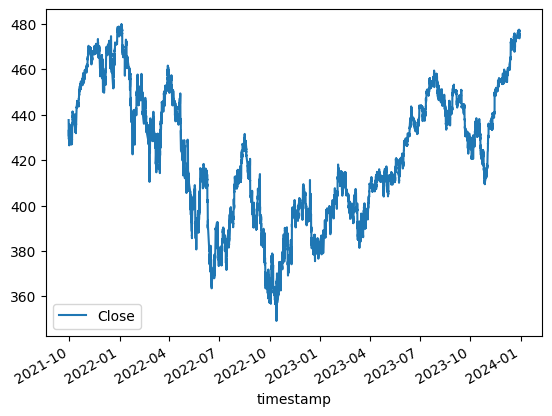

In [11]:
FilteredSP500Data
##Plot de data (fix the x axis labels, those are overlapping)
##Plot the data with the same x axis labels
FilteredSP500Data.plot(x_compat=True)

In [12]:

# # do it (stop commenting)

# groupedbyDay = FilteredSP500Data.groupby(FilteredSP500Data.index.date)

# # Calculate difference between the first and last value of the day
# dailyDiff = groupedbyDay.apply(lambda x: x.iloc[-1] - x.iloc[0])

# # Order the daily Diff with the biggest losses first
# dailyDiff.sort_values(by='Close', ascending=True, inplace=True)

# # Add year-month column
# dailyDiff['YearMonth'] = dailyDiff.index.to_series().apply(lambda x: f'{x.year}-{x.month}')

# #Group by year-month and sum Close column

# monthlyLosses = dailyDiff.groupby('YearMonth').sum('Close')

# monthlyLosses.sort_values(by='Close', ascending=True, inplace=True)


In [ ]:
#filter de dataset by Year 2022 and month April (de dataset has time stamp as index)
#Date List Files
DD202204 = FilteredSP500Data[(FilteredSP500Data.index.year == 2022) & (FilteredSP500Data.index.month == 4)]
DD202209 = FilteredSP500Data[(FilteredSP500Data.index.year == 2022) & (FilteredSP500Data.index.month == 9)]

In [14]:
#DD202204.plot(x_compat=True)

In [15]:
# DD202209.plot(x_compat=True)

# Experimentos

In [17]:
tickers = ['AAPL','ABCB','CSCO','DAL','EAST','ESPR','F',
           'GOOGL','JPM','META','MSFT','NVDA','PFE','PG','PSX',
           'SGLY','SP500','TSLA','UNH','USA','WMT','XOM']

VAR_DATA_PATH = '../Data/enriched_data'

In [18]:
def get_data(tickers, data_path):
    training_data = {}
    for tick in tickers:
        training_data[tick] = pd.read_parquet(f'{data_path}/{tick}_training_data.pk')
    return training_data

In [19]:
# ticker of benchmark
benchmark = 'SP500'

# Getting data
training_data = get_data(tickers, data_path=VAR_DATA_PATH)

In [ ]:
from StockTradingEnv import StockTradingEnv
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from datetime import datetime
import os
from Charts.ploTools import *
from Charts.resumeTools import *

In [4]:
#Parameters
RETURN_MEMORY_SIZE = 5
REWARD_TYPE = 'sharpewithcorrelation'
CORRELATION_PUNISHMENT = 1
INITIAL_BALANCE = 100000
VAR_EPISODE_STEP_CONST = 64 
VAR_TESTING_POINTS =  20
N_TOTAL_EPISODES = 20

EXPERIMENT_PATH = 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3/'


PathAgentList = glob(EXPERIMENT_PATH+'*/*/DDPG Agent_model.zip')

In [5]:
PathAgentList

['OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\000000\\2024-11-09_18-37-02_133\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\000001\\2024-11-09_18-59-33_320\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000010\\2024-11-09_23-25-02_349\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000011\\2024-11-09_23-54-52_114\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000012\\2024-11-10_00-17-34_265\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000013\\2024-11-10_00-39-26_267\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000014\\2024-11-10_01-01-17_870\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000015\\2024-11-10_01-23-17_299\\DDPG Agent_model.zip',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\000001

# DD202204

In [ ]:
ResultFolderName = 'DD202204_' + EXPERIMENT_PATH.split('/')[1]
# Create a folder if it doesn't exist
if not os.path.exists(f"TestingDrawdownResults/{ResultFolderName}"):
    os.makedirs(f"TestingDrawdownResults/{ResultFolderName}")

In [23]:
def createAndSaveTesting(DFDates , PATH_AGENT_FILE, pathToSave, i):
    # Step0: Lista de fechas de los testing points
    date_list = DFDates.index.to_list()
    date_list = [date.date() for date in date_list]
    # Step1: Filter training data by the dates of the testing points
    testing_data = filter_data_for_testing(training_data, date_list)
    benchmark_testing_data = testing_data['SP500']
    # Step2: Create a new environment with the filtered data
    env_testing = DummyVecEnv([lambda: StockTradingEnv(testing_data, benchmark_testing_data, return_memory_size=RETURN_MEMORY_SIZE, reward_type=REWARD_TYPE,env_correlation_punishment=CORRELATION_PUNISHMENT, env_initial_balance=INITIAL_BALANCE)])

    benchmark_testing_data = testing_data['SP500']
    # Step2: Create a new environment with the filtered data
    env_testing = DummyVecEnv([lambda: StockTradingEnv(testing_data, benchmark_testing_data, return_memory_size=RETURN_MEMORY_SIZE, reward_type=REWARD_TYPE,env_correlation_punishment=CORRELATION_PUNISHMENT, env_initial_balance=INITIAL_BALANCE)])
    # Step3: Load the agents
    ddpg_agent = LoadedDDPGAgent(env_testing, seed=0, hp_params={},path=PATH_AGENT_FILE)
    sp500_agent = SP500Agent(env_testing)
    agentsToTest = {'DDPG Agent': ddpg_agent, 'SP500 Agent': sp500_agent}
    # Step3: Test the best/last agents with the new environment
    metrics_resume_testing, _ , _ = getResumeMetrics(env_testing, agentsToTest, episode_step_const=VAR_EPISODE_STEP_CONST ,n_total_episodes=N_TOTAL_EPISODES, testing_points=VAR_TESTING_POINTS, just_test=True)
    # Step4: Save the results
    with open(f'{pathToSave}/{i}_testing_results.pk', 'wb') as file:
        pickle.dump(metrics_resume_testing, file)
    return f"Iteration {i} Done!"


In [24]:
i = 0
for pathAgent in PathAgentList:
    print(createAndSaveTesting(DD202204 , pathAgent, f'TestingDrawdownResults/{ResultFolderName}' , i))
    i+=1

Stock data has been loaded for 22 stocks.
The tickers are: ['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Stock data has been loaded for 22 stocks.
The tickers are: ['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Tickers en init SP500Agent
['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
--------------Testing Point 1 of 20-----------------------------------
--------------Testing Point 2 of 20-----------------------------------
--------------Testing Point 3 of 20-----------------------------------
--------------Testing Point 4 of 20-----------------------------------
--------------Testing Point 5 of 20-----------------------------------
--

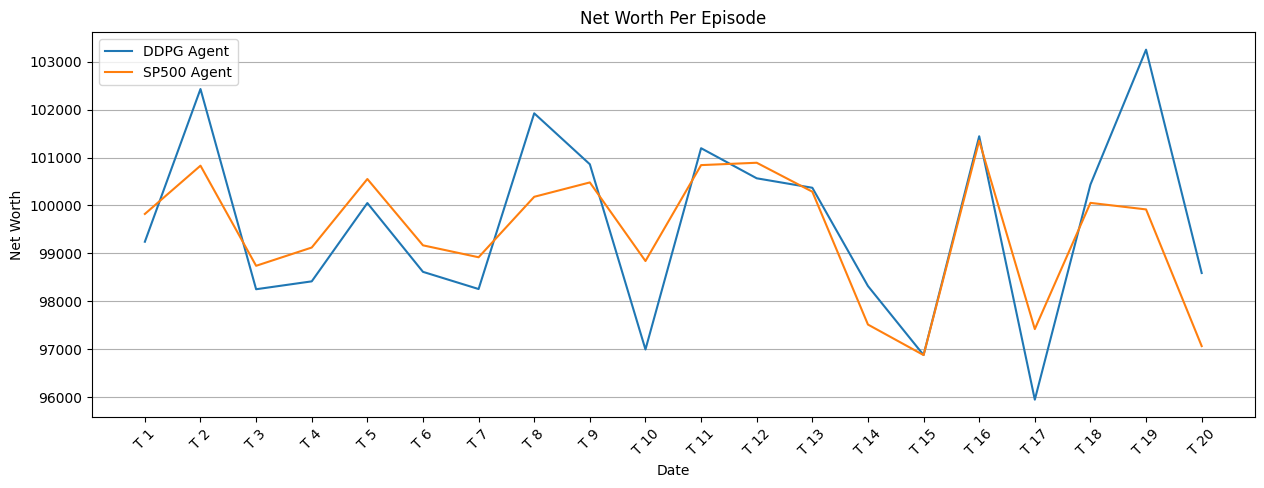

In [26]:
PATH_DATA_LIST_METRICS_RESUME_TESTING  = glob(f'TestingDrawdownResults/{ResultFolderName}' + "/*_testing_results.pk")
metrics_resume_testing_avg = mean_resume_data(PATH_DATA_LIST_METRICS_RESUME_TESTING)
endPlotNetWorthMultiAgents(metrics_resume_testing_avg)

In [27]:
print('Para el agente DDPG el valor promedio del net_worths fue:' ,np.mean(metrics_resume_testing_avg['DDPG Agent']['net_worths']))
print('Para el agente SP500 el valor promedio del net_worths fue:' ,np.mean(metrics_resume_testing_avg['SP500 Agent']['net_worths']))


Para el agente DDPG el valor promedio del net_worths fue: 99601.74072678831
Para el agente SP500 el valor promedio del net_worths fue: 99443.86112259998


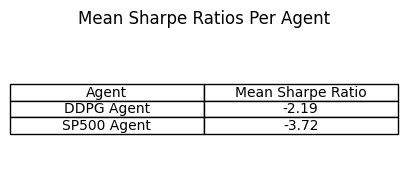

In [28]:
plotTableMeanSharpeRatioMultiAgents(metrics_resume_testing_avg)

# DD202209 

In [41]:
ResultFolderName = 'DD202209_' + EXPERIMENT_PATH.split('/')[1]
# Create a folder if it doesn't exist
if not os.path.exists(f"TestingDrawdownResults/{ResultFolderName}"):
    os.makedirs(f"TestingDrawdownResults/{ResultFolderName}")

In [42]:
i = 0
for pathAgent in PathAgentList:
    print(createAndSaveTesting(DD202209 , pathAgent, f'TestingDrawdownResults/{ResultFolderName}' , i))
    i+=1

Stock data has been loaded for 22 stocks.
The tickers are: ['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Stock data has been loaded for 22 stocks.
The tickers are: ['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
Tickers en init SP500Agent
['AAPL', 'ABCB', 'CSCO', 'DAL', 'EAST', 'ESPR', 'F', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'PSX', 'SGLY', 'SP500', 'TSLA', 'UNH', 'USA', 'WMT', 'XOM']
--------------Testing Point 1 of 20-----------------------------------
--------------Testing Point 2 of 20-----------------------------------
--------------Testing Point 3 of 20-----------------------------------
--------------Testing Point 4 of 20-----------------------------------
--------------Testing Point 5 of 20-----------------------------------
--

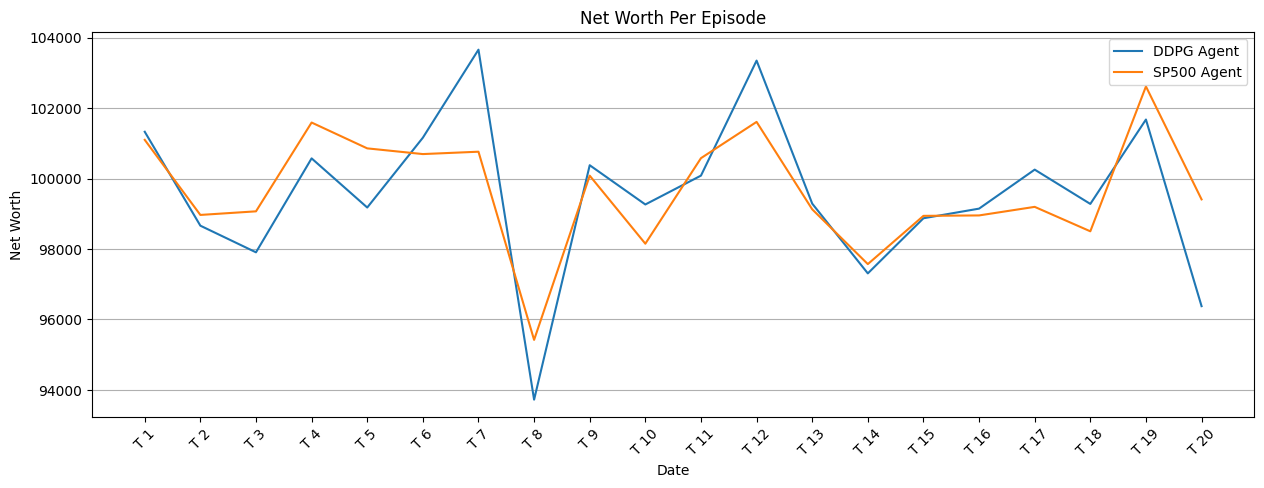

In [43]:
PATH_DATA_LIST_METRICS_RESUME_TESTING  = glob(f'TestingDrawdownResults/{ResultFolderName}' + "/*_testing_results.pk")
metrics_resume_testing_avg = mean_resume_data(PATH_DATA_LIST_METRICS_RESUME_TESTING)
endPlotNetWorthMultiAgents(metrics_resume_testing_avg)

In [44]:
print('Para el agente DDPG el valor promedio del net_worths fue:' ,np.mean(metrics_resume_testing_avg['DDPG Agent']['net_worths']))
print('Para el agente SP500 el valor promedio del net_worths fue:' ,np.mean(metrics_resume_testing_avg['SP500 Agent']['net_worths']))

Para el agente DDPG el valor promedio del net_worths fue: 99572.6882356103
Para el agente SP500 el valor promedio del net_worths fue: 99659.14123450001


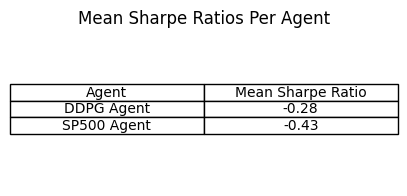

In [45]:
plotTableMeanSharpeRatioMultiAgents(metrics_resume_testing_avg)